In [1]:
import pandas as pd
from math import cos, radians, sqrt
from sklearn.neighbors import BallTree
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
import warnings
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
import statsmodels.formula.api as smf
from scipy.stats import skew, kurtosis
from scipy.stats import wilcoxon
from scipy.stats import mannwhitneyu
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import StrMethodFormatter
from statsmodels.stats.anova import anova_lm
from scipy.stats import shapiro
from statsmodels.stats.multitest import multipletests
from matplotlib.ticker import FuncFormatter

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
np.set_printoptions(suppress = True)
# np.set_printoptions(precision = 3)

In [3]:
raw = "C:\\Users\\taavi\\Desktop\\BPHIL\\Raw data\\"
clean = "C:\\Users\\taavi\\Desktop\\BPHIL\\Clean data\\"
images = 'C:\\Users\\taavi\\Desktop\\BPHIL\\Images in defense ppt\\'

In [4]:
parcels = pd.read_csv(clean + 'blight.csv')
#parcels = pd.read_csv(clean + 'blight_and_values.csv')

In [169]:
d = pd.read_csv(clean + 'clean_demos.csv')

In [4]:
demos = pd.read_csv(clean + 'clean_demos.csv')

In [6]:
values = pd.read_csv(clean + 'clean_values.csv')

### Getting 'demos_decayed'

In [13]:
years = range(values['year'].min(), values['year'].max() + 1)

In [ ]:
full = pd.DataFrame()

earthRadius = 6_378_137 # meters

distances = np.arange(50, 800, 50)
distances_radians = distances / earthRadius
weights = [(i + 1) / len(distances) for i, r in enumerate(distances)][::-1]

for year in tqdm(years):
    parcels_sub = parcels.loc[parcels['year'] == year].reset_index(drop = True)
    demos_sub = demos.loc[pd.to_datetime(demos['date'], format = 'mixed').dt.year == year].reset_index(drop = True)

    parcels_coords = np.radians(parcels_sub[['lat', 'lng']].to_numpy())
    demos_coords = np.radians(demos_sub[['lat', 'lng']].to_numpy())

    demo_tree = BallTree(demos_coords, metric = 'haversine')
    
    # count and sum values in each distance bin
    for d_m, d_r in zip(distances, distances_radians):
        indices_within_radius = demo_tree.query_radius(parcels_coords, r = d_r)
        counts = [len(idxs) for idxs in indices_within_radius]
        parcels_sub[f'demos_count_{d_m}'] = counts

    for i, r in enumerate(distances[::-1]):
        if r != distances[0]:
            parcels_sub[f'demos_count_{r}'] -= parcels_sub[f'demos_count_{distances[::-1][i + 1]}']

    parcels_sub['demos_decayed'] = (parcels_sub.iloc[:, -len(distances):] * weights).sum(axis = 1)

        
    full = pd.concat([full, parcels_sub], axis = 0)

full = full.reset_index(drop = True)

In [ ]:
full['demos_decayed'].value_counts(normalize = True)

In [ ]:
full.groupby('year')['demos_decayed'].mean()

In [ ]:
full.groupby(['year', 'blight'])['demos_decayed'].mean()[28:]

### Dataset of demos with values, then assigning blight cluster with a merge on parcelID

In [31]:
demos = demos[['parcelID', 'date', 'lat', 'lng', 'value', 'comm_res']]
demos['year'] = pd.to_datetime(demos['date'], format = 'mixed').dt.year
demos = demos.sort_values(by = ['year', 'parcelID']).reset_index(drop = True)

#### Extending demos temporally

In [32]:
years = pd.date_range(start = values['date'].min(), end = '2025-12-31', freq = 'Y')

In [ ]:
demos = demos.merge(pd.DataFrame({'date': years}), how = 'cross').sort_values(by = 'date').reset_index(drop = True)
demos['date'] = demos['date'].dt.year
demos = demos.rename(columns = {'date': 'year'}).sort_values(by = ['parcelID', 'year']).reset_index(drop = True)

In [73]:
full = pd.DataFrame()

earthRadius = 6_378_137 # meters

distances = np.arange(50, 800, 50)
distances_radians = distances / earthRadius
weights = [(i + 1) / len(distances) for i, r in enumerate(distances)][::-1]

for year in tqdm(years):
    demos_sub = demos.loc[demos['year'] == year.year].reset_index(drop = True)
    values_sub = values.loc[values['year'] == year.year].reset_index(drop = True)

    parcels_coords = np.radians(demos_sub[['lat', 'lng']].to_numpy())
    values_coords = np.radians(values_sub[['lat', 'lng']].to_numpy())

    value_tree = BallTree(values_coords, metric = 'haversine')
    
    # count and sum values in each distance bin
    for d_m, d_r in zip(distances, distances_radians):
        indices_within_radius = value_tree.query_radius(parcels_coords, r = d_r)
        counts = [len(idxs) for idxs in indices_within_radius]
        demos_sub[f'values_count_{d_m}'] = counts

        sums = [values_sub.loc[idxs, 'value'].sum() for idxs in indices_within_radius]
        demos_sub[f'values_sum_{d_m}'] = sums

    demos_sub = demos_sub.fillna(0)

    for i, r in enumerate(distances[::-1]):
        if r != distances[0]:
            demos_sub[f'values_count_{r}'] -= demos_sub[f'values_count_{distances[::-1][i + 1]}']
            demos_sub[f'values_sum_{r}'] -= demos_sub[f'values_sum_{distances[::-1][i + 1]}']
    
    demos_sub['values_count_decayed'] = (demos_sub.iloc[:, -len(distances) * 2::2] * weights).sum(axis = 1)
    demos_sub['values_sum_decayed'] = (demos_sub.iloc[:, -len(distances) * 2::2] * weights).sum(axis = 1)

    demos_sub['values_decayed'] = demos_sub['values_sum_decayed'] / demos_sub['values_count_decayed']

    full = pd.concat([full, demos_sub], axis = 0)

full = full.reset_index(drop = True)

100%|██████████| 10/10 [00:34<00:00,  3.42s/it]


In [74]:
demos = full.copy()

### Smoothing, deltas, and column cleanup

In [75]:
train = demos.loc[(demos['values_decayed'].isna() == False)]
x = train[['lat', 'lng']]
y = train['values_decayed']

knn = KNeighborsRegressor(n_neighbors = 5)
demos.loc[(demos['values_decayed'].isna()) | (demos['values_decayed'] == 0), 'values_decayed'] = knn.fit(x, y).predict(demos.loc[(demos['values_decayed'].isna()) | (demos['values_decayed'] == 0), ['lat', 'lng']])

demos = demos.sort_values(by = ['parcelID', 'year']).reset_index(drop = True)

same_parcel_prev_1 = demos['parcelID'].eq(demos['parcelID'].shift(1))
same_parcel_prev_2 = demos['parcelID'].eq(demos['parcelID'].shift(2))
same_parcel_prev_3 = demos['parcelID'].eq(demos['parcelID'].shift(3))
same_parcel_prev_4 = demos['parcelID'].eq(demos['parcelID'].shift(4))
same_parcel_prev_5 = demos['parcelID'].eq(demos['parcelID'].shift(5))

demos = (
    demos
    .assign(
        past_1 = demos['values_decayed'].shift(1).where(same_parcel_prev_1),
        past_2 = demos['values_decayed'].shift(2).where(same_parcel_prev_2),
        past_3 = demos['values_decayed'].shift(3).where(same_parcel_prev_3),
        past_4 = demos['values_decayed'].shift(4).where(same_parcel_prev_4),
        past_5 = demos['values_decayed'].shift(5).where(same_parcel_prev_5),
    )
    .assign(
        values_smoothed = lambda x: pd.concat([x['values_decayed'], x['past_1'], x['past_2'], x['past_3'], x['past_4'], x['past_5']], axis = 1).mean(axis = 1)
    )
    .assign(
        nom_delta_1 = lambda x: x['values_smoothed'].diff(1).where(same_parcel_prev_1).shift(-1),
        nom_delta_2 = lambda x: x['values_smoothed'].diff(2).where(same_parcel_prev_2).shift(-2),
        nom_delta_3 = lambda x: x['values_smoothed'].diff(3).where(same_parcel_prev_3).shift(-3),
        nom_delta_4 = lambda x: x['values_smoothed'].diff(4).where(same_parcel_prev_4).shift(-4),
        nom_delta_5 = lambda x: x['values_smoothed'].diff(5).where(same_parcel_prev_5).shift(-5),
        pct_delta_1 = lambda x: x['values_smoothed'].pct_change(1).where(same_parcel_prev_1).shift(-1),
        pct_delta_2 = lambda x: x['values_smoothed'].pct_change(2).where(same_parcel_prev_2).shift(-2),
        pct_delta_3 = lambda x: x['values_smoothed'].pct_change(3).where(same_parcel_prev_3).shift(-3),
        pct_delta_4 = lambda x: x['values_smoothed'].pct_change(4).where(same_parcel_prev_4).shift(-4),
        pct_delta_5 = lambda x: x['values_smoothed'].pct_change(5).where(same_parcel_prev_5).shift(-5),
    )
    .assign(
        cagr_1 = lambda x: ((x['pct_delta_1'] + 1) ** (1/1)) - 1,
        cagr_2 = lambda x: ((x['pct_delta_2'] + 1) ** (1/2)) - 1,
        cagr_3 = lambda x: ((x['pct_delta_3'] + 1) ** (1/3)) - 1,
        cagr_4 = lambda x: ((x['pct_delta_4'] + 1) ** (1/4)) - 1,
        cagr_5 = lambda x: ((x['pct_delta_5'] + 1) ** (1/5)) - 1
    )
    .reset_index(drop = True)
    [['parcelID', 'lat', 'lng', 'demo_year', 'year', 'values_smoothed', 'nom_delta_1', 'nom_delta_2', 'nom_delta_3', 'nom_delta_4', 'nom_delta_5',
      'pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5', 'cagr_1', 'cagr_2', 'cagr_3', 'cagr_4', 'cagr_5']]
)

In [76]:
print('MEAN')
print(demos[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].mean())
print('STDEV')
print(demos[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].std())
print('\n')
print('MEDIAN')
print(demos[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].median())
print('IQR')
print(demos[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].quantile(0.75) -
      demos[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].quantile(0.25))

MEAN
pct_delta_1   0.13
pct_delta_2   0.23
pct_delta_3   0.40
pct_delta_4   0.53
pct_delta_5   0.68
dtype: float64
STDEV
pct_delta_1   0.40
pct_delta_2   0.49
pct_delta_3   1.01
pct_delta_4   0.99
pct_delta_5   1.16
dtype: float64


MEDIAN
pct_delta_1   0.05
pct_delta_2   0.12
pct_delta_3   0.20
pct_delta_4   0.30
pct_delta_5   0.41
dtype: float64
IQR
pct_delta_1   0.13
pct_delta_2   0.26
pct_delta_3   0.41
pct_delta_4   0.57
pct_delta_5   0.73
dtype: float64


### Merging blight from parcels

In [7]:
demos = demos.merge(right = parcels[['parcelID', 'nbrhd', 'blight', 'blight_sqrt']].drop_duplicates(subset = 'parcelID'), on = 'parcelID', how = 'inner')

In [78]:
demos.to_csv(clean + 'demos_values_blight.csv', index = False)

In [44]:
demos = pd.read_csv(clean + 'demos_values_blight.csv')

### Investigating the relationship between demos and values, given underlying levels of blight

In [79]:
demos_testing = demos.loc[demos['demo_year'] == demos['year']]

In [80]:
model = smf.ols(formula = 'values_smoothed ~ C(blight_sqrt)', data = demos_testing).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        values_smoothed   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     65.83
Date:                Sun, 14 Sep 2025   Prob (F-statistic):           1.70e-68
Time:                        09:52:16   Log-Likelihood:                -12855.
No. Observations:                 961   AIC:                         2.572e+04
Df Residuals:                     954   BIC:                         2.576e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             1.92e+05   2

In [4]:
parcels = pd.read_csv(clean + 'blight_and_values.csv')
parcels['blight_sqrt'] = parcels['blight_sqrt'].astype(str)
parcels = parcels.loc[parcels['year'] >= 2020]

In [7]:
parcels = pd.read_csv(clean + 'blight_and_values.csv')
parcels['blight_sqrt'] = parcels['blight_sqrt'].astype(str)
parcels['value_mean'] = parcels.groupby('parcelID')['values_smoothed'].transform('mean')
demos = demos.loc[demos['demo_year'] == demos['year']]
demos['blight_sqrt'] = demos['blight_sqrt'].astype(str)
parcels = parcels.drop_duplicates(subset = 'parcelID')
exposure = pd.read_csv(clean + 'parcels_demo_exposure.csv')

KeyError: 'demo_year'

In [ ]:
exposure = pd.read_csv(clean + 'parcels_demo_exposure.csv')

In [ ]:
# demo_ids = demos['parcelID'].unique()
high_exposure_ids = exposure.loc[exposure['high_exposure'] == 1]['parcelID'].unique()
# pop_control = parcels.loc[~parcels['parcelID'].isin(demo_ids)]
pop_control = parcels.loc[~parcels['parcelID'].isin(high_exposure_ids)]
high_exposure_subset = parcels.loc[parcels['parcelID'].isin(high_exposure_ids)]

In [ ]:
# demo_ids = demos['parcelID'].unique()
high_exposure_ids = exposure.loc[exposure['high_exposure'] == 1]['parcelID'].unique()
# pop_control = parcels.loc[~parcels['parcelID'].isin(demo_ids)]
pop_control = parcels.loc[~parcels['parcelID'].isin(high_exposure_ids)]
high_exposure_subset = parcels.loc[parcels['parcelID'].isin(high_exposure_ids)]

# Step 2: create a list to hold results
results = []

# Step 3: loop over each blight cluster
for c in sorted(parcels['blight_sqrt'].unique()):
    demo_vals = high_exposure_subset.loc[high_exposure_subset['blight_sqrt'] == c, 'values_smoothed']
    control_vals = pop_control.loc[pop_control['blight_sqrt'] == c, 'value_mean']
    
    n_demo = len(demo_vals)
    n_control = len(control_vals)
    
    if n_demo == 0 or n_control == 0:
        continue
    
    # Mann-Whitney U test
    stat, p_val = mannwhitneyu(demo_vals, control_vals, alternative='two-sided')
    
    # Median values
    median_demo = demo_vals.median()
    median_control = control_vals.median()
    
    # Median difference (demo - control)
    median_diff = median_demo - median_control
    
    # Optional: rank-biserial effect size
    effect_size = 1 - (2 * stat / (n_demo * n_control))
    
    results.append({
        'Blight': c,
        'n_demo': n_demo,
        'n_control': n_control,
        'Median_demo': median_demo,
        'Median_control': median_control,
        'Median_diff': median_diff,
        'U_stat': stat,
        'p_value': p_val,
        'Effect_size': effect_size
    })

# Step 4: convert to DataFrame
summary_table = pd.DataFrame(results)

# Step 5: display
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
summary_table[['Blight', 'n_demo', 'n_control', 'Median_demo', 'Median_control', 'p_value']]

,Blight,n_demo,n_control,Median_demo,Median_control,p_value
0,5,1583,30206,"27,587.23","108,446.56",0.00
1,6,3793,8358,"29,066.43","209,947.27",0.00


In [ ]:
demo_vals.shape

In [ ]:
sns.kdeplot(parcels['value_mean'])
plt.show()

In [ ]:
skew(parcels['value_mean'])

In [ ]:
sns.kdeplot(demos['values_smoothed'])
plt.show()

In [ ]:
skew(demos['values_smoothed'])

In [ ]:
parcels['value_mean'].std() ** 2, demos['values_smoothed'].std() ** 2

In [ ]:
for c in demos.sort_values(by = 'blight_sqrt')['blight_sqrt'].unique():
    sub = parcels.loc[parcels['blight_sqrt'] == c]
    n = sub.shape[0]
    print('Cluster:', c)
    print(round(sub['value_mean'].median(), 1))
    print('n:', n)
    print('\n')

In [ ]:
for c in demos.sort_values(by = 'blight_sqrt')['blight_sqrt'].unique():
    sub = demos.loc[demos['blight_sqrt'] == c]
    n = sub.shape[0]
    print('Cluster:', c)
    print(round(sub['values_smoothed'].median(), 1))
    print('n:', n)
    print('\n')

In [ ]:
for c in demos['blight_sqrt'].unique():
    sub = parcels.loc[parcels['blight_sqrt'] == c]
    n = sub.shape[0]
    print('Cluster:', c)
    print(sub[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].median())
    print('n:', n)
    print('\n')

In [ ]:
for c in demos['blight_sqrt'].unique():
    sample = demos.loc[demos['demo_year'] == demos['year']]
    sub = sample.loc[sample['blight_sqrt'] == c]
    n = sub.shape[0]
    print('Cluster:', c)
    print(sub[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].median())
    print('n:', n)
    print('\n')

In [ ]:
fig = px.scatter_mapbox(demos, lat = 'lat', lon = 'lng', color = 'Blight', color_discrete_map = color_discrete_map, zoom = 10,
                        category_orders = {'Blight': ['1', '2', '3', '4', '5', '6', '7', 'Demo']}, hover_data = ['Neighborhood'])
fig.update_layout(mapbox_style = 'carto-positron')
fig.show()

In [80]:
exposure.groupby('high_exposure')['blight_sqrt'].value_counts()

high_exposure  blight_sqrt
0              3              39123
               2              34215
               5              30206
               1              14755
               4              11044
               6               8358
               7                954
1              6               3793
               5               1583
Name: count, dtype: int64

In [16]:
demos['blight_sqrt'].value_counts(normalize = True)

blight_sqrt
4   0.2716
2   0.2376
5   0.2207
1   0.1024
6   0.0844
3   0.0767
7   0.0066
Name: proportion, dtype: float64

In [45]:
demos.groupby(['year', 'high_exposure'])['blight_sqrt'].value_counts(normalize = True).reset_index().loc[lambda x: x['high_exposure'] == 1]

,year,high_exposure,blight_sqrt,proportion
7,2020,1,6,0.33
8,2020,1,5,0.26
9,2020,1,4,0.24
10,2020,1,2,0.08
11,2020,1,3,0.07
12,2020,1,1,0.02
20,2021,1,5,0.45
21,2021,1,6,0.37
22,2021,1,4,0.16
23,2021,1,3,0.01


# START HERE

In [4]:
parcels = pd.read_csv(clean + 'blight_and_values.csv')
parcels = parcels.loc[parcels['year'] >= 2020]
demos = pd.read_csv(clean + 'blight_and_demos.csv')
parcels['blight_sqrt'] = parcels['blight_sqrt'].astype(str)
parcels['value_mean'] = parcels.groupby('parcelID')['values_smoothed'].transform('mean')
demos['blight_sqrt'] = demos['blight_sqrt'].astype(str)
#distance = pd.read_csv(clean + 'parcels_avg_distance.csv')

In [5]:
parcels = parcels.merge(right = demos[['parcelID', 'year', 'exposure', 'demos_sum_decayed']], on = ['parcelID', 'year'], how = 'left')

In [27]:
pct_cols = [f'pct_delta_{i + 1}' for i in range(5)]
nom_cols = [f'nom_delta_{i + 1}' for i in range(5)]

#### Testing for skew and distribution

In [37]:
group = parcels.groupby(['blight_sqrt', 'exposure'])
sqrt_group = (
    parcels
    [pct_cols].apply(lambda x: np.sqrt(np.abs(x)) * np.sign(x), axis = 0)
    .assign(
        blight_sqrt = parcels['blight_sqrt'],
        exposure = parcels['exposure']
    )
    .groupby(['blight_sqrt', 'exposure'])
)

In [40]:
def shapiro_test(series):
    s = series.dropna()
    if len(s) < 3:
        return pd.Series({'W': None, 'p': None})
    W, p = shapiro(s)
    return pd.Series({'W': W, 'p': p})

normality = parcels.groupby(['blight_sqrt', 'exposure'])[pct_cols].apply(lambda df: df.apply(shapiro_test))
sqrt_normality = (
    parcels
    [pct_cols].apply(lambda x: np.sqrt(np.abs(x)) * np.sign(x), axis = 0)
    .assign(
        blight_sqrt = parcels['blight_sqrt'],
        exposure = parcels['exposure']
    )
    .groupby(['blight_sqrt', 'exposure'])[pct_cols].apply(lambda df: df.apply(shapiro_test))
)

In [7]:
agg_dict = (
    {pct_col: 'median' for pct_col in pct_cols} |
    {nom_col: 'median' for nom_col in nom_cols} |
    {'parcelID': 'nunique'} |
    {'values_smoothed': 'median'}
)
agg = parcels.query('year == 2020').groupby(['blight_sqrt','exposure']).agg(agg_dict).reset_index()

In [8]:
agg

,blight_sqrt,exposure,pct_delta_1,pct_delta_2,pct_delta_3,pct_delta_4,pct_delta_5,nom_delta_1,nom_delta_2,nom_delta_3,nom_delta_4,nom_delta_5,parcelID,values_smoothed
0,1,High,0.02,0.04,0.07,0.08,0.08,"12,381.00","20,464.91","38,992.53","46,050.40","46,558.92",423,"553,259.75"
1,1,Low,0.04,0.12,0.14,0.22,0.28,"5,138.82","15,643.88","20,165.62","27,939.92","34,278.20",21600,"121,709.06"
2,2,High,0.07,0.18,0.22,0.20,0.24,"14,202.62","37,471.57","46,896.15","47,461.09","58,831.50",1809,"222,401.35"
3,2,Low,0.05,0.14,0.18,0.22,0.29,"5,891.57","17,758.58","23,304.72","27,940.74","35,584.81",33398,"111,910.39"
4,3,High,0.06,0.13,0.21,0.23,0.26,"10,191.64","22,805.70","30,215.91","39,330.07","34,596.36",3198,"202,119.02"
5,3,Low,0.05,0.15,0.21,0.26,0.33,"5,437.34","15,287.46","21,824.00","28,647.59","36,511.13",33709,"108,055.07"
6,4,High,-0.01,0.02,0.02,0.06,-0.01,"-6,420.86","8,243.38","8,245.53","24,253.65","-3,995.97",1168,"447,487.11"
7,4,Low,0.01,0.03,0.07,0.11,0.16,"4,072.02","8,759.63","26,220.41","37,927.37","53,217.27",10457,"363,181.12"
8,5,High,0.05,0.18,0.30,0.44,0.51,"4,040.93","9,841.58","13,482.69","21,955.65","31,222.81",4088,"53,863.35"
9,5,Low,0.05,0.15,0.22,0.29,0.39,"5,237.88","13,933.57","20,219.08","26,921.74","43,474.69",22023,"102,257.73"


In [9]:
high = agg.loc[agg['exposure'] == 'High'].reset_index(drop = True).set_index('blight_sqrt')
low = agg.loc[agg['exposure'] == 'Low'].reset_index(drop = True).set_index('blight_sqrt')

what_it_would_be = low[pct_cols].apply(lambda x: (1 + x) * high['values_smoothed'], axis = 0)
what_it_would_be.columns = nom_cols

what_it_is = high[nom_cols].apply(lambda x: x + high['values_smoothed'], axis = 0)

nom_difs = what_it_is - what_it_would_be

total_value_add = nom_difs.apply(lambda x: x * high['parcelID'], axis = 0)
total_value_add

,nom_delta_1,nom_delta_2,nom_delta_3,nom_delta_4,nom_delta_5
blight_sqrt,,,,,
1,"-5,250,027.25","-19,401,663.03","-16,936,775.14","-31,222,110.56","-45,856,204.09"
2,"6,504,381.21","9,508,414.24","11,458,074.90","-3,279,422.41","-10,641,703.66"
3,"212,323.93","-22,652,813.14","-36,290,565.98","-44,999,816.09","-105,621,254.76"
4,"-14,519,388.39","-6,500,869.45","-26,086,091.57","-28,868,207.40","-86,326,298.14"
5,"4,682,620.53","7,015,094.89","5,711,209.23","25,203,037.62","41,697,520.19"
6,"13,880,172.45","64,299,925.55","55,199,733.52","82,635,084.27","97,592,399.71"
7,NaN,NaN,NaN,NaN,NaN


In [10]:
just_demos = pd.read_csv(clean + 'clean_demos.csv')

In [11]:
investments = (
    just_demos
    .assign(year = pd.to_datetime(just_demos['date']).dt.year)
    .query('status == "Completed"')
    [['parcelID', 'value']]
    .merge(right = parcels[['parcelID', 'blight_sqrt', 'exposure']], on = 'parcelID', how = 'left')
    .loc[lambda x: x['exposure'] == 'High']
    .groupby('blight_sqrt')['value'].sum()
    .reset_index()
    .set_index('blight_sqrt')
)
investments

,value
blight_sqrt,
1,"1,155,506.00"
2,"2,266,417.00"
3,"9,280,088.00"
4,"4,157,500.00"
5,"14,986,726.00"
6,"19,737,159.00"
7,"292,500.00"


In [12]:
total_value_add['nom_delta_5'] / investments['value'] - 1

blight_sqrt
1   -40.68
2    -5.70
3   -12.38
4   -21.76
5     1.78
6     3.94
7      NaN
dtype: float64

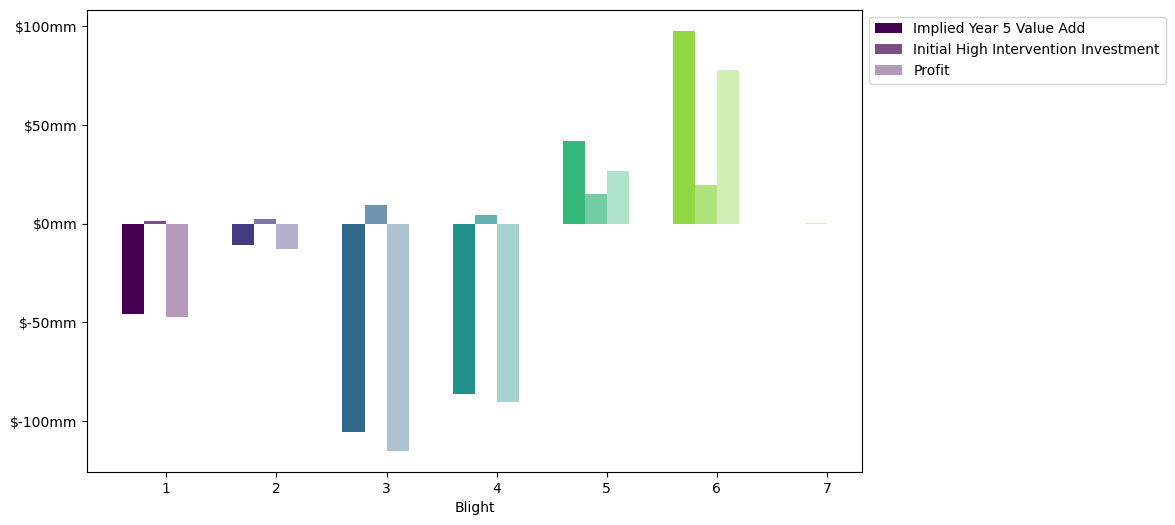

In [45]:
ROIs = pd.DataFrame({
    'Implied Year 5 Value Add': total_value_add['nom_delta_5'],
    'Initial High Intervention Investment': investments['value'],
    'Profit': total_value_add['nom_delta_5'] - investments['value'],
    #'Return on Investment': total_value_add['nom_delta_5'] / investments['value'] - 1
}).reset_index().rename(columns = {'blight_sqrt': 'blight'}).melt(id_vars = 'blight')


blight_cats = list(range(1, 8))
vars = ['Implied Year 5 Value Add', 'Initial High Intervention Investment', 'Profit']

n_cats = len(blight_cats)
n_vars = len(vars)

base_colors = [cm.viridis(i / (n_cats - 1)) for i in range(n_cats)]
alphas = np.linspace(1.0, 0.4, n_vars)

bar_width = 0.2
x = np.arange(n_cats)

fig, ax = plt.subplots(figsize=(10, 6))

for j, var in enumerate(vars):
    subset = ROIs[ROIs['variable'] == var].set_index('blight')#.reindex(blight_cats)
    for i, (cat, base) in enumerate(zip(blight_cats, base_colors)):
        r, g, b, _ = base
        color = (r, g, b, alphas[j])
        ax.bar(
            x[i] + j * bar_width - (n_vars * bar_width / 2),
            subset.loc[str(cat), 'value'],
            width=bar_width,
            color=color,
            label=var if i == 0 else None
        )

ax.set_xticks(x)
ax.set_xticklabels(blight_cats)
ax.set_xlabel('Blight')
ax.set_ylabel('')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1_000_000:,.0f}mm'))
ax.legend(bbox_to_anchor = (1, 1), loc = 'upper left')


# plt.figure(figsize = (8, 6))
# sns.barplot(ROIs, x = 'blight', y = 'value', hue = 'variable')
# plt.xlabel('Blight')
# plt.ylabel('')

plt.savefig(images + 'return_investment_profit_by_blight.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [43]:
subset.loc['1']

variable    Implied Year 5 Value Add
value                 -45,856,204.09
Name: 1, dtype: object

In [21]:
total_value_add['nom_delta_5'] - investments['value']

blight_sqrt
1    -47,011,710.09
2    -12,908,120.66
3   -114,901,342.76
4    -90,483,798.14
5     26,710,794.19
6     77,855,240.71
7               NaN
dtype: float64

### Conclusion:
In the case of category 6, the city spent $18,919,454.00 for a 1-year yield of $12,391,605.73 and a 5-year yield of $93,780,843.28, or a 395.7% 5-year return. For category 5, the 5-year return is 416.4%. The suppressive effects of high intervention in the other categories 

In [28]:
control = parcels.loc[parcels['exposure'] == 'Low']
treatment = parcels.loc[parcels['exposure'] == 'High']

agg_cols = (
    {'blight_sqrt': 'first'} |
    {f'pct_delta_{i}': 'median' for i in range(1, 6)}
)

control_collapsed = control.groupby('parcelID').agg(agg_cols)
treatment_collapsed = treatment.groupby('parcelID').agg(agg_cols)


# Step 3: loop over pct_delta columns
all_results_pre = []

for col in pct_cols:
    results = []
    for c in sorted(parcels['blight_sqrt'].unique()):
        # demo_vals = high_exposure_subset.loc[high_exposure_subset['blight_sqrt'] == c, col].dropna()
        # control_vals = pop_control.loc[pop_control['blight_sqrt'] == c, col].dropna()

        demo_vals = treatment_collapsed.query('blight_sqrt == @c')[col].dropna()
        control_vals = control_collapsed.query('blight_sqrt == @c')[col].dropna()
        
        n_demo = len(demo_vals)
        n_control = len(control_vals)
        
        if n_demo == 0 or n_control == 0:
            continue
        
        # Mann-Whitney U test
        stat, p_val = mannwhitneyu(demo_vals, control_vals, alternative = 'two-sided')
        
        # Median values
        median_demo = demo_vals.median()
        median_control = control_vals.median()
        
        # Median difference (demo - control)
        median_diff = median_demo - median_control
        
        # Rank-biserial effect size
        effect_size = 1 - (2 * stat / (n_demo * n_control))

        # skew_demo = high_exposure_subset.loc[high_exposure_subset['blight_sqrt'] == c, col].dropna().skew()
        # skew_control = pop_control.loc[pop_control['blight_sqrt'] == c, col].dropna().skew()

        # kurt_demo = kurtosis(high_exposure_subset.loc[high_exposure_subset['blight_sqrt'] == c, col].dropna())
        # kurt_control = kurtosis(pop_control.loc[pop_control['blight_sqrt'] == c, col].dropna())

        skew_demo = demo_vals.skew()
        skew_control = control_vals.skew()

        kurt_demo = kurtosis(treatment_collapsed.loc[treatment_collapsed['blight_sqrt'] == c, col].dropna())
        kurt_control = kurtosis(control_collapsed.loc[control_collapsed['blight_sqrt'] == c, col].dropna())
        
        results.append({
            'Blight_Cluster': c,
            'Pct_Delta': col,
            'n_demo': n_demo,
            'n_control': n_control,
            'Median_demo': median_demo,
            'Median_control': median_control,
            'Median_diff': median_diff,
            'U_stat': stat,
            'p_value': p_val,
            'skew_demo': skew_demo,
            'skew_control': skew_control,
            'kurt_demo': kurt_demo,
            'kurt_control': kurt_control,
            #'Effect_size': effect_size
        })
    
    all_results_pre.extend(results)

# Step 4: convert to DataFrame
summary_table_pct = pd.DataFrame(all_results_pre)#.assign(demo_to_control = lambda x: x['Median_demo'] / x['Median_control'])

summary_table_pct['p_value_BH'] = multipletests(
    summary_table_pct['p_value'],
    alpha = 0.01,
    method = 'fdr_bh'
)[1]

# Step 5: display nicely
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
#summary_table_pct.sort_values(by = ['Blight_Cluster', 'Pct_Delta'])

In [30]:
cat_7_concat_rows = pd.DataFrame(np.array([
    [7, 'pct_delta_2'] + [0]*2 + [0.0]*5 + [0] * 5,
    [7, 'pct_delta_3'] + [0]*2 + [0.0]*5 + [0] * 5,
    [7, 'pct_delta_4'] + [0]*2 + [0.0]*5 + [0] * 5,
    [7, 'pct_delta_5'] + [0]*2 + [0.0]*5 + [0] * 5
]), columns = summary_table_pct.columns)

In [31]:
summary_table_pct = pd.concat([summary_table_pct, cat_7_concat_rows], axis = 0)

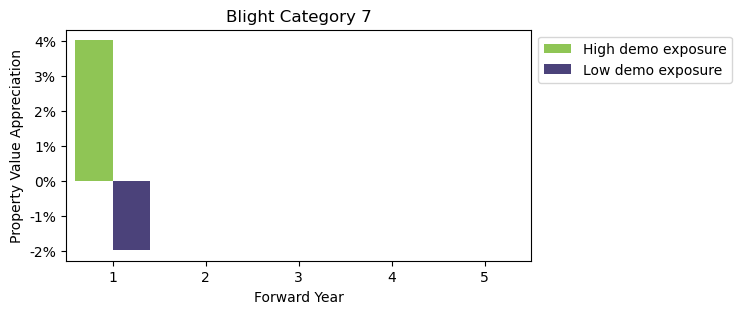

In [39]:
cmap = {
    'High demo exposure': '#90d743',
    'Low demo exposure': '#443983'
}

toPlot = (
        summary_table_pct
        .loc[summary_table_pct['Blight_Cluster'] == '7']
        .assign(Forward_Year = lambda x: [str(i + 1) for i in range(x.shape[0])])
        .rename(columns = {'Forward_Year': 'Forward Year', 'Median_demo': 'High demo exposure', 'Median_control': 'Low demo exposure'})
        [['Forward Year', 'High demo exposure', 'Low demo exposure']]
        .melt(
            id_vars = 'Forward Year'
        )
        .rename(columns = {'variable': 'Group', 'value': 'Property Value Percent Change'})
        .merge(
            right = summary_table_pct.loc[summary_table_pct['Blight_Cluster'] == '7'].assign(Forward_Year = lambda x: [str(i + 1) for i in range(x.shape[0])])[['Forward_Year', 'p_value']].rename(columns = {'Forward_Year': 'Forward Year'}),
            on = 'Forward Year', how = 'left'
        )
    )

toPlot['Property Value Percent Change'] = toPlot['Property Value Percent Change'].astype(float)

plt.figure(figsize = (6, 3))
sns.barplot(toPlot, x = 'Forward Year', y = 'Property Value Percent Change', hue = 'Group', palette = cmap, errorbar = None)
#signifs = toPlot.loc[toPlot['p_value'] < 0.01]['Forward Year'].values
# for s in signifs:
#     plt.axvline(x = s, color = 'black', linestyle = '--')
plt.title(f'Blight Category 7')
plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1))
plt.ylabel('Property Value Appreciation')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:,.0f}%'))

plt.show()

In [38]:
toPlot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Forward Year                   10 non-null     object
 1   Group                          10 non-null     object
 2   Property Value Percent Change  10 non-null     object
 3   p_value                        10 non-null     object
dtypes: object(4)
memory usage: 452.0+ bytes


In [33]:
toPlot

,Forward Year,Group,Property Value Percent Change,p_value
0,1,High demo exposure,0.0403,0.0000
1,2,High demo exposure,0.0,0.0
2,3,High demo exposure,0.0,0.0
3,4,High demo exposure,0.0,0.0
4,5,High demo exposure,0.0,0.0
5,1,Low demo exposure,-0.0199,0.0000
6,2,Low demo exposure,0.0,0.0
7,3,Low demo exposure,0.0,0.0
8,4,Low demo exposure,0.0,0.0
9,5,Low demo exposure,0.0,0.0


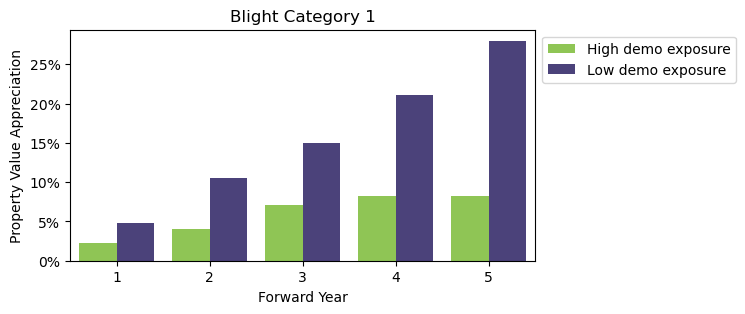

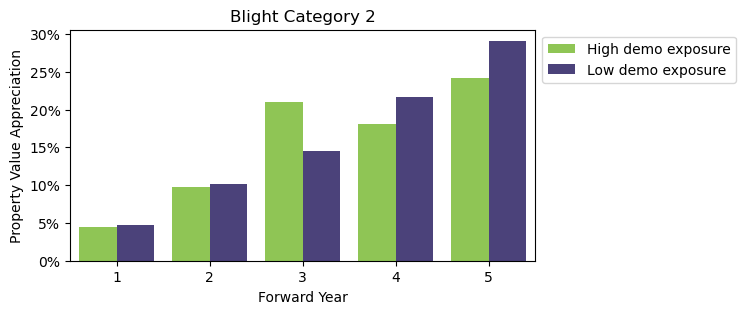

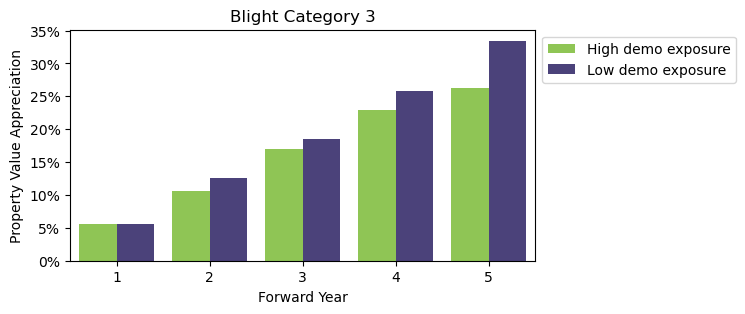

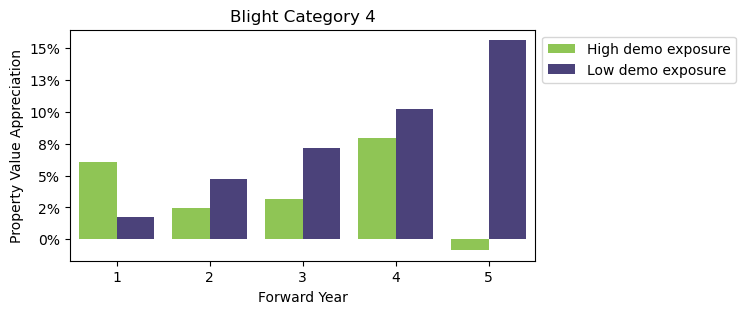

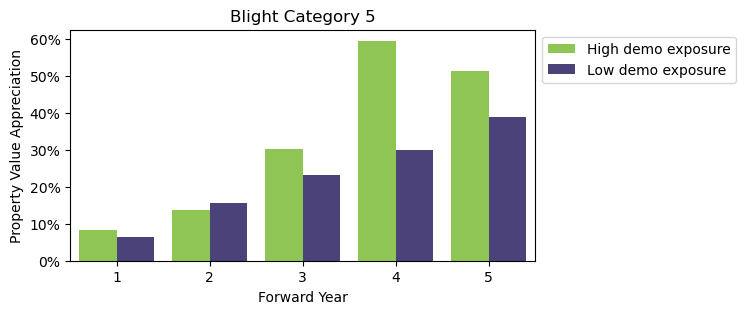

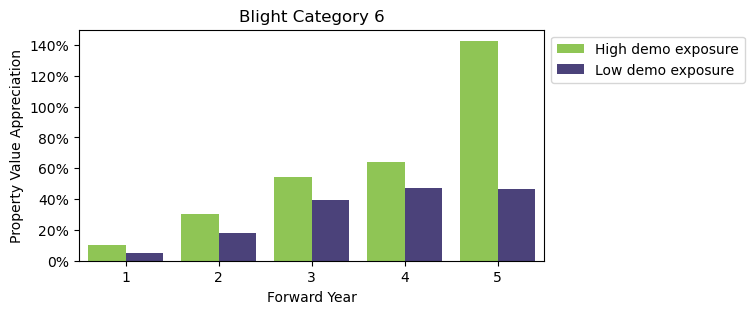

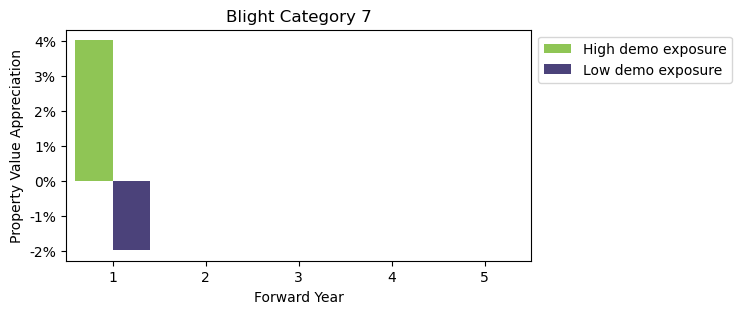

In [40]:
cmap = {
    'High demo exposure': '#90d743',
    'Low demo exposure': '#443983'
}

for i in ['1', '2', '3', '4', '5', '6', '7']:
    toPlot = (
        summary_table_pct
        .loc[summary_table_pct['Blight_Cluster'] == i]
        .assign(Forward_Year = lambda x: [str(i + 1) for i in range(x.shape[0])])
        .rename(columns = {'Forward_Year': 'Forward Year', 'Median_demo': 'High demo exposure', 'Median_control': 'Low demo exposure'})
        [['Forward Year', 'High demo exposure', 'Low demo exposure']]
        .melt(
            id_vars = 'Forward Year'
        )
        .rename(columns = {'variable': 'Group', 'value': 'Property Value Percent Change'})
        .merge(
            right = summary_table_pct.loc[summary_table_pct['Blight_Cluster'] == i].assign(Forward_Year = lambda x: [str(i + 1) for i in range(x.shape[0])])[['Forward_Year', 'p_value']].rename(columns = {'Forward_Year': 'Forward Year'}),
            on = 'Forward Year', how = 'left'
        )
    )

    toPlot['Property Value Percent Change'] = toPlot['Property Value Percent Change'].astype(float)

    plt.figure(figsize = (6, 3))
    sns.barplot(toPlot, x = 'Forward Year', y = 'Property Value Percent Change', hue = 'Group', palette = cmap)
    #signifs = toPlot.loc[toPlot['p_value'] < 0.01]['Forward Year'].values
    # for s in signifs:
    #     plt.axvline(x = s, color = 'black', linestyle = '--')
    plt.title(f'Blight Category {i}')
    plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1))
    plt.ylabel('Property Value Appreciation')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:,.0f}%'))
    plt.savefig(images + f'mann_whitney_U_cat_{i}.png', dpi = 300, bbox_inches = 'tight')
    plt.show()

In [8]:
pop_control = parcels.loc[parcels['high_exposure'] == 0]
high_exposure_subset = parcels.loc[parcels['high_exposure'] == 1]

# Step 3: loop over pct_delta columns
all_results_pre = []

for col in pct_cols:
    results = []
    for c in sorted(parcels['nbrhd'].unique()):
        demo_vals = high_exposure_subset.loc[high_exposure_subset['nbrhd'] == c, col]#.dropna()
        control_vals = pop_control.loc[pop_control['nbrhd'] == c, col]#.dropna()
        
        n_demo = len(demo_vals)
        n_control = len(control_vals)
        
        if n_demo == 0 or n_control == 0:
            continue
        
        # Mann-Whitney U test
        stat, p_val = mannwhitneyu(demo_vals, control_vals, alternative = 'two-sided')
        
        # Median values
        median_demo = demo_vals.median()
        median_control = control_vals.median()
        
        # Median difference (demo - control)
        median_diff = median_demo - median_control
        
        # Rank-biserial effect size
        effect_size = 1 - (2 * stat / (n_demo * n_control))

        skew_demo = high_exposure_subset.loc[high_exposure_subset['nbrhd'] == c, col].dropna().skew()
        skew_control = pop_control.loc[pop_control['nbrhd'] == c, col].dropna().skew()

        kurt_demo = kurtosis(high_exposure_subset.loc[high_exposure_subset['nbrhd'] == c, col].dropna())
        kurt_control = kurtosis(pop_control.loc[pop_control['nbrhd'] == c, col].dropna())
        
        results.append({
            'Neighborhood': c,
            'Pct_Delta': col,
            'n_demo': n_demo,
            'n_control': n_control,
            'Median_demo': median_demo,
            'Median_control': median_control,
            'Median_diff': median_diff,
            'U_stat': stat,
            'p_value': p_val,
            'skew_demo': skew_demo,
            'skew_control': skew_control,
            'kurt_demo': kurt_demo,
            'kurt_control': kurt_control,
            #'Effect_size': effect_size
        })
    
    all_results_pre.extend(results)

# Step 4: convert to DataFrame
summary_table_pct = pd.DataFrame(all_results_pre)#.assign(demo_to_control = lambda x: x['Median_demo'] / x['Median_control'])

# Step 5: display nicely
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
summary_table_pct.sort_values(by = ['Neighborhood', 'Pct_Delta'])

,Neighborhood,Pct_Delta,n_demo,n_control,Median_demo,Median_control,Median_diff,U_stat,p_value,skew_demo,skew_control,kurt_demo,kurt_control
0,Allegheny Center,pct_delta_1,3,381,NaN,-0.0168,NaN,NaN,NaN,NaN,0.2429,NaN,-0.7897
66,Allegheny Center,pct_delta_2,3,381,NaN,-0.0418,NaN,NaN,NaN,NaN,0.6961,NaN,-0.8273
132,Allegheny Center,pct_delta_3,3,381,NaN,0.0532,NaN,NaN,NaN,NaN,0.9883,NaN,0.1193
198,Allegheny Center,pct_delta_4,3,381,NaN,0.0935,NaN,NaN,NaN,NaN,0.1506,NaN,-0.5788
264,Allegheny Center,pct_delta_5,3,381,NaN,0.2347,NaN,NaN,NaN,NaN,-0.6556,NaN,-1.0868
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,West Oakland,pct_delta_1,290,4222,-0.1170,-0.0290,-0.0880,NaN,NaN,0.3754,-0.7670,-1.8124,0.2397
131,West Oakland,pct_delta_2,290,4222,-0.0888,-0.0300,-0.0588,NaN,NaN,0.3268,-0.5538,-1.6879,-0.5779
197,West Oakland,pct_delta_3,290,4222,-0.0693,-0.0381,-0.0312,NaN,NaN,-0.2393,-0.4083,0.5636,-1.0664
263,West Oakland,pct_delta_4,290,4222,-0.1995,-0.0945,-0.1050,NaN,NaN,0.4541,0.5399,0.4478,0.6672
